In [1]:
import pandas as pd
import itertools
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# DATA

In [2]:
df_out = pd.read_csv("01B_garden_compare_rda.tsv", sep="\t", header=0)
df_out.head()

marker_labels = pd.DataFrame({"marker":["100", "100LF", "1000","10000","1000LF", "all","lfmm","RDA","RDAcorrected"],
                             "Marker":["0.1K", "0.1K-lf", "1K","1K-lf","10K", "~29K","LFMM","RDA","RDA-struct"]})
df = pd.merge(df_out, marker_labels, on = "marker", how = "left")
df.head()

df = df[df["Marker"].isin(["0.1K", "0.1K-lf", "1K","1K-lf","~29K","LFMM","RDA","RDA-struct"])].reset_index(drop=True)
df[df["Marker"].isna()]

,sample,SITE_ID,offset_rda,marker,trait,Trait_name,POP_SITE,POP_ID,SET,mean,sd,n,group,Marker


# Get paiwise correlations

In [3]:
df_sub = df[(df["SITE_ID"] == "ML") & (df["trait"] == "Height") & (df["SET"] == "TEST")].reset_index(drop=True)
df_sub.head()

,sample,SITE_ID,offset_rda,marker,trait,Trait_name,POP_SITE,POP_ID,SET,mean,sd,n,group,Marker
0,1329_ML,ML,0.140716,100,Height,Height,1329_ML,1329,TEST,1435.746514,165.025251,3.0,East,0.1K
1,1528_ML,ML,0.105867,100,Height,Height,1528_ML,1528,TEST,1424.030354,75.498344,3.0,East,0.1K
2,1530_ML,ML,0.237639,100,Height,Height,1530_ML,1530,TEST,976.829721,155.349069,3.0,East,0.1K
3,1531_ML,ML,0.116011,100,Height,Height,1531_ML,1531,TEST,1186.591020,130.000000,3.0,East,0.1K
4,1534_ML,ML,0.061497,100,Height,Height,1534_ML,1534,TEST,1367.178745,110.151411,3.0,East,0.1K


In [4]:
# Get all unique factors and their pairwise combinations

def get_pearsons_corr(dataset):
    factors = dataset["Marker"].unique()
    pairs = list(itertools.combinations(factors, 2))
    pairs
    
    results = []
    
    for f1, f2 in pairs:
        v1 = dataset.loc[dataset["Marker"] == f1, "offset_rda"].values
        v2 = dataset.loc[dataset["Marker"] == f2, "offset_rda"].values
    
        # Only compare if both have the same number of observations
        n = min(len(v1), len(v2))
        rho, pval = pearsonr(v1[:n], v2[:n])
        rho, pval = pearsonr(v1, v2)
        results.append({"marker1": f1, "marker2": f2, "r": rho, "p": pval, "n" : n})
    
    pairwise_corr = pd.DataFrame(results)
    return(pairwise_corr)

In [5]:
get_pearsons_corr(df_sub).head()

,marker1,marker2,r,p,n
0,0.1K,0.1K-lf,0.899549,3.048948e-15,40
1,0.1K,1K,0.984862,1.561964e-30,40
2,0.1K,1K-lf,0.983610,6.989394e-30,40
3,0.1K,~29K,0.982468,2.490532e-29,40
4,0.1K,LFMM,0.982496,2.415334e-29,40


# Loop

In [6]:
R = []
for site in ["PR","ML","CH","AC"]:
    for trait in df['trait'].drop_duplicates().values:
        df_sub = df[(df["SITE_ID"] == site) & (df["trait"] == trait) & (df["SET"] == "TEST")].reset_index(drop=True)

        df_corrs = get_pearsons_corr(df_sub)
        df_corrs['SITE_ID'] = site
        df_corrs['trait'] = trait
        R.append(df_corrs)
dR = pd.concat(R, ignore_index=True)
dR.head()

,marker1,marker2,r,p,n,SITE_ID,trait
0,0.1K,0.1K-lf,0.993268,5.530698e-24,26.0,PR,Height
1,0.1K,1K,0.993776,2.160340e-24,26.0,PR,Height
2,0.1K,1K-lf,0.996161,6.643667e-27,26.0,PR,Height
3,0.1K,~29K,0.996137,7.156150e-27,26.0,PR,Height
4,0.1K,LFMM,0.428844,2.881488e-02,26.0,PR,Height


### Saving

In [7]:
dR.to_csv("14_compare_offsets.tsv", sep="\t", header=True, index=False)

# Plots

In [10]:
wide = df_sub[["POP_ID","Marker","offset_rda"]].pivot(index="POP_ID", columns="Marker", values="offset_rda")
wide
corr_matrix = wide.corr(method="pearson")
corr_matrix

Marker,0.1K,0.1K-lf,1K,1K-lf,LFMM,RDA,RDA-struct,~29K
Marker,,,,,,,,
0.1K,1.000000,0.996095,0.991231,0.992801,0.855850,0.733807,0.733807,0.992702
0.1K-lf,0.996095,1.000000,0.998331,0.998794,0.844674,0.707644,0.707644,0.998917
1K,0.991231,0.998331,1.000000,0.999726,0.831613,0.720212,0.720212,0.999829
1K-lf,0.992801,0.998794,0.999726,1.000000,0.841512,0.721180,0.721180,0.999976
LFMM,0.855850,0.844674,0.831613,0.841512,1.000000,0.570718,0.570718,0.839690
RDA,0.733807,0.707644,0.720212,0.721180,0.570718,1.000000,1.000000,0.718934
RDA-struct,0.733807,0.707644,0.720212,0.721180,0.570718,1.000000,1.000000,0.718934
~29K,0.992702,0.998917,0.999829,0.999976,0.839690,0.718934,0.718934,1.000000


In [11]:
order = ["0.1K", "0.1K-lf", "1K","1K-lf", "~29K","LFMM","RDA","RDA-struct"]
corr_matrix = corr_matrix.loc[order, order]
#print(corr_matrix)

<Axes: xlabel='Marker', ylabel='Marker'>

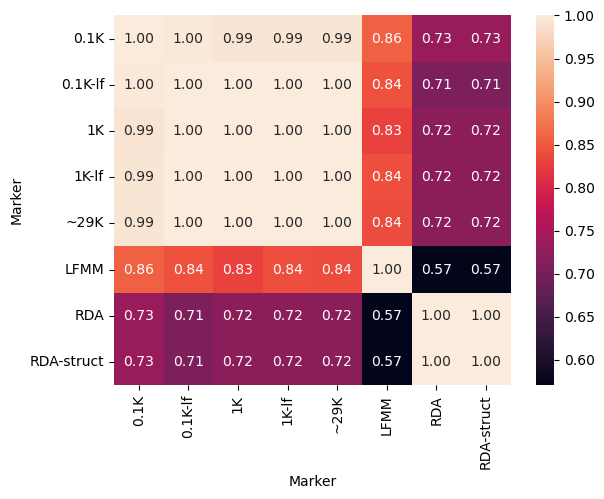

In [12]:
sns.heatmap(data = corr_matrix, annot=True,         # add labels inside cells
    fmt=".2f",)